finite diff on a uniform  
chebyshev and why use them  
how it doesn't work for classical bvp discretization  
explain fornberg  
Matrix representation  
BVP with fornbeg  
compare all errors  
Computation analysis  

# Introduction
We're used to the finite differences we've seen in class that are done on uniform grids  

### Example: Central Difference  

$u'(t) = \frac{u_{i+1} - u_{i-1}}{2h} + O(h^2)$  

We derive these by taking the taylor series expansion of u(x+h) and u(x-h) and combining them  
But, what happens when the grid is no longer uniform?  

### Chebyshev Nodes of the 2nd type 
$x_i = cos(\frac{i \pi}{N})$ for i=0,1,...,N  

No longer uniform i.e. no uniform choice of h and hence combining u(x+h) becomes u(x+$h_r$) and u(x-h) becomes u(x-$h_l$) which no longer easily cancel terms  

Why Chebyshev nodes / a non-uniform grid :  
Runge effect : large oscillations near the edges of an interval  


# Fornberg Algorithm

### Lagrange polynomials
$u(x) \approx L(x) = \sum l_i(x) y_i$  
The kth derivative of u can be approximated via the kth derivative of the lagrange polynomial of u  
$u^{(k)}(x) \approx \sum l^{(k)}_i(x) y_i$  
Now, compare this to the general finite difference of u at the kth derivative  
$u^{(k)}(x) \approx \sum c^{(k)}_i(x) u(x_i)$    
These are the same thing!  

### Big Idea
The big idea is, if we can somehow efficiently compute the kth derivative of each lagrange basis, we will have the weights for the kth derivative  

### First Update Rule $c_{i,j}$ 
Recurrence relation for lagrange basises  
(1) $l_{i,j}(x) = \frac{x-x_j}{x_i - x_j} l_{i,j-1}$  
And  
$l_{i,j} = l_{i,j} + xl'_{i,j} + \frac{x^2}{2} l''_{i,j} + ...$      

We say $l_{i,j} = c_{i,j}$  
(2) $l_{i,j} = \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^k}{k!}$      

Substituting (2) into (1)  
$ \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^k}{k!} = \frac{x-x_j}{x_i - x_j} \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^k}{k!}$  

$ = \frac{1}{x_i - x_j} [ x \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^k}{k!} -  x_j \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^k}{k!}]$  

We can choose m = k+1 to simplify the first  
$x \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^k}{k!} = \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^{k+1}}{k!}$  

Choosing m=k+1 and knowing $(m-1)! = \frac{m!}{m}$  

$= \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^{m}}{m!} m$  

We can then change our choice of dummy variables so they match (m=k)  
$ \frac{1}{x_i - x_j} [ \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^{k-1}}{k!}k -  x_j \sum^j_{k=0} c^{(k)}_{i,j} \frac{x^k}{k!}] = $  

Matching the coefficients we get our first update rule (for $i \neq j)$  
(3) $c^(k)_{i,j} = \frac{1}{x_i x_j} (x_j c^k _{i,j-1} - kc^{k-1}_{i,j-1})$  

### Second Update Rule $c_{i,i}$
We can express $l_j,j$ equivalently. You can check it yourself, it simplifies down to $l_{j,j}$ that we're used to  
$l_{j,j}(x) = \frac{\prod_{\nu=0}^{j-2}(x_{j-1} - x_\nu)}{\prod_{\nu=0}^{j-1}(x_j - x_\nu)} (x - x_{j-1}) l_{j-1,j-1}(x)$  
Plugging in (2)  
$\sum^j_{k=0} c^{(k)}_{j,j} \frac{x^k}{k!} = \frac{\prod_{\nu=0}^{j-2}(x_{j-1} - x_\nu)}{\prod_{\nu=0}^{j-1}(x_j - x_\nu)} (x - x_{j-1}) \sum^{j-1}_{k=0} c^{(k)}_{j-1,j-1} \frac{x^k}{k!}$  
Ignoring the fraction, it follows a similar format to the previous update equation so we can skip derivation  

And get our second update rule (for i=j)  
(4) $c^(k)_{j,j} = \frac{\prod_{\nu=0}^{j-2}(x_{j-1} - x_\nu)}{\prod_{\nu=0}^{j-1}(x_j - x_\nu)} \frac{1}{x_i x_j} (-x_{j-1} c^k _{j-1,j-1} + kc^{k-1}_{j-1,j-1})$  



In [2]:
# chebyshev nodes of second kind
a,b = -1,1
N=10
function chebyshev_nodes(a,b,N)
    X = []
    for i in 0:N
        x = cos(i*π/N)
        push!(X,x)
        # println(x)
    end
    return X
end
chebyshev_nodes(-1,1,4)
# calculate_weights(1,3chebyshev_nodes(a,b,N))


5-element Vector{Any}:
  1.0
  0.7071067811865476
  6.123233995736766e-17
 -0.7071067811865475
 -1.0

In [9]:
#############################################################
# Fornberg algorithm

# This implements the Fornberg (1988) algorithm (https://doi.org/10.1090/S0025-5718-1988-0935077-0)
# to obtain Finite Difference weights over arbitrary points to arbitrary order.

function calculate_weights(order::Int, x0::T, x::AbstractVector) where {T <: Real}
    #=
        order: The derivative order for which we need the coefficients
        x0   : The point in the array 'x' for which we need the coefficients
        x    : A dummy array with relative coordinates, e.g., central differences
               need coordinates centred at 0 while those at boundaries need
               coordinates starting from 0 to the end point

        The approximation order of the stencil is automatically determined from
        the number of requested stencil points.
    =#
    N = length(x)
    @assert order<N "Not enough points for the requested order."
    M = order
    c1 = one(T)
    # x0 : number to evaulate finite difference at
    # (x0 - x_n) -> base : (x_s - x0)
    c4 = x[1] - x0
    # weight matrix : result of this algorithm
    C = zeros(T, N, M + 1)
    # base case : 1*f^0(x0) = f^0(x0)
    C[1, 1] = 1
    # run for each node in column : num of nodes in [a,b]
    @inbounds for i in 1:(N - 1)
        i1 = i + 1
        mn = min(i, M)
        c2 = one(T)
        # (x_n-1 -x_s)
        c5 = c4
        # (x_s - x_n) : x_s = x[i1] 
        c4 = x[i1] - x0
        for j in 0:(i - 1)
            j1 = j + 1
            # x_s - 
            c3 = x[i1] - x[j1]
            c2 *= c3
            if j == i - 1
                for s in mn:-1:1
                    s1 = s + 1
                    C[i1, s1] = c1 * (s * C[i, s] - c5 * C[i, s1]) / c2
                    display(C)
                end
                C[i1, 1] = -c1 * c5 * C[i, 1] / c2
            end
            for s in mn:-1:1
                s1 = s + 1
                C[j1, s1] = (c4 * C[j1, s1] - s * C[j1, s]) / c3
                display(C)
            end
            C[j1, 1] = c4 * C[j1, 1] / c3
            display(C)
        end
        c1 = c2
    end
    #=
        This is to fix the problem of numerical instability which occurs when the sum of the stencil_coefficients is not
        exactly 0.
        https://scicomp.stackexchange.com/questions/11249/numerical-derivative-and-finite-difference-coefficients-any-update-of-the-fornb
        Stack Overflow answer on this issue.
        http://epubs.siam.org/doi/pdf/10.1137/S0036144596322507 - Modified Fornberg Algorithm
    =#
    _C = C[:, end]
    if order != 0
        _C[div(N, 2) + 1] -= sum(_C)
    end
    display(C)
    return _C
end

# 11 nodes ∈ [-1,1]
X = chebyshev_nodes(-1,1,10)
# calculate a matrix whos 3rd column gives weights to multiply by f(x_i)
# w0*f(x0) + w1*f(x1) + ... + wn*f(xn)
calculate_weights(Int(3),X[5],X)

11


11×4 Matrix{Float64}:
 1.0    0.0     0.0  0.0
 0.0  -20.4317  0.0  0.0
 0.0    0.0     0.0  0.0
 0.0    0.0     0.0  0.0
 0.0    0.0     0.0  0.0
 0.0    0.0     0.0  0.0
 0.0    0.0     0.0  0.0
 0.0    0.0     0.0  0.0
 0.0    0.0     0.0  0.0
 0.0    0.0     0.0  0.0
 0.0    0.0     0.0  0.0

11×4 Matrix{Float64}:
  1.0     20.4317  0.0  0.0
 14.118  -20.4317  0.0  0.0
  0.0      0.0     0.0  0.0
  0.0      0.0     0.0  0.0
  0.0      0.0     0.0  0.0
  0.0      0.0     0.0  0.0
  0.0      0.0     0.0  0.0
  0.0      0.0     0.0  0.0
  0.0      0.0     0.0  0.0
  0.0      0.0     0.0  0.0
  0.0      0.0     0.0  0.0

11×4 Matrix{Float64}:
 -13.118   20.4317  0.0  0.0
  14.118  -20.4317  0.0  0.0
   0.0      0.0     0.0  0.0
   0.0      0.0     0.0  0.0
   0.0      0.0     0.0  0.0
   0.0      0.0     0.0  0.0
   0.0      0.0     0.0  0.0
   0.0      0.0     0.0  0.0
   0.0      0.0     0.0  0.0
   0.0      0.0     0.0  0.0
   0.0      0.0     0.0  0.0

11×4 Matrix{Float64}:
 -13.118   20.4317  213.964  0.0
  14.118  -20.4317    0.0    0.0
   0.0      0.0       0.0    0.0
   0.0      0.0       0.0    0.0
   0.0      0.0       0.0    0.0
   0.0      0.0       0.0    0.0
   0.0      0.0       0.0    0.0
   0.0      0.0       0.0    0.0
   0.0      0.0       0.0    0.0
   0.0      0.0       0.0    0.0
   0.0      0.0       0.0    0.0

...

11×4 Matrix{Float64}:
  0.0  -0.723607    -1.84721     73.8334
 -0.0   1.55754      4.31972   -156.002
  0.0  -2.0         -7.31672    182.337
 -0.0   3.58721     24.5106    -142.006
  1.0  -0.17082    -37.7062     -20.2625
  0.0  -3.23607     22.0498     151.995
 -0.0   1.61803     -5.78885   -154.93
  0.0  -1.11507      2.86773    116.542
 -0.0   0.894427    -1.90557    -96.0631
  0.0  -0.0296725    1.53074     86.127
 -0.0   0.381966    -0.714087   -41.5709

11×4 Matrix{Float64}:
  0.0  -0.723607   -1.84721     73.8334
 -0.0   1.55754     4.31972   -156.002
  0.0  -2.0        -7.31672    182.337
 -0.0   3.58721    24.5106    -142.006
  1.0  -0.17082   -37.7062     -20.2625
  0.0  -3.23607    22.0498     151.995
 -0.0   1.61803    -5.78885   -154.93
  0.0  -1.11507     2.86773    116.542
 -0.0   0.894427   -1.90557    -96.0631
  0.0  -0.793604    1.53074     86.127
 -0.0   0.381966   -0.714087   -41.5709

11×4 Matrix{Float64}:
  0.0  -0.723607   -1.84721     73.8334
 -0.0   1.55754     4.31972   -156.002
  0.0  -2.0        -7.31672    182.337
 -0.0   3.58721    24.5106    -142.006
  1.0  -0.17082   -37.7062     -20.2625
  0.0  -3.23607    22.0498     151.995
 -0.0   1.61803    -5.78885   -154.93
  0.0  -1.11507     2.86773    116.542
 -0.0   0.894427   -1.90557    -96.0631
  0.0  -0.793604    1.53074     86.127
 -0.0   0.381966   -0.714087   -41.5709

11×4 Matrix{Float64}:
  0.0  -0.723607   -1.84721     73.8334
 -0.0   1.55754     4.31972   -156.002
  0.0  -2.0        -7.31672    182.337
 -0.0   3.58721    24.5106    -142.006
  1.0  -0.17082   -37.7062     -20.2625
  0.0  -3.23607    22.0498     151.995
 -0.0   1.61803    -5.78885   -154.93
  0.0  -1.11507     2.86773    116.542
 -0.0   0.894427   -1.90557    -96.0631
  0.0  -0.793604    1.53074     86.127
 -0.0   0.381966   -0.714087   -41.5709

11-element Vector{Float64}:
   73.83343685400047
 -156.00194753013392
  182.33685303601726
 -142.00606234406575
  -20.26252583997984
  151.99503100797588
 -154.93002067198375
  116.5422942560796
  -96.06314696398267
   86.12699921009335
  -41.57091101402061

In [3]:
# Example Solving Differential Equation
f(x) = -π^2 * sin(π * x)
α = 0.0
β = 0.0


N = 16  # number of interior resolution
X = chebyshev_nodes(-1, 1, N)

# Build the second-derivative matrix
D2 = zeros(N+1, N+1)
for i in 1:(N+1)
    D2[i, :] = calculate_weights(2, X[i], X)
end

f_vec = f.(X)

# Overwrite first and last rows with BC equations
D2[1, :] .= 0;   D2[1, 1] = 1;     f_vec[1] = α
D2[end, :] .= 0;  D2[end, end] = 1;  f_vec[end] = β

u = D2 \ f_vec

17×3 Matrix{Float64}:
  1.0    85.5       4369.0
  0.0  -104.087    -6964.78
 -0.0    26.2741    3802.55
  0.0   -11.8673   -1888.47
 -0.0     6.82843   1121.03
  0.0    -4.50015   -749.274
 -0.0     3.23983    543.514
  0.0    -2.48475   -418.718
 -0.0     2.0        338.0
  0.0    -1.67351   -283.37
 -0.0     1.44646    245.253
  0.0    -1.2857    -218.202
 -0.0     1.17157    198.966
  0.0    -1.09202   -185.543
 -0.0     1.03957    176.685
  0.0    -1.0097    -171.639
 -0.0     0.5         85.0

17×3 Matrix{Float64}:
 -0.0   26.0217     2037.96
  1.0  -12.8846    -2923.63
  0.0  -17.5729     1070.46
 -0.0    6.69722    -262.288
  0.0   -3.65392     120.861
 -0.0    2.35175     -71.6644
  0.0   -1.67196      48.676
 -0.0    1.27276     -36.0379
  0.0   -1.01959      28.3533
 -0.0    0.85043     -23.3614
  0.0   -0.733424     19.9756
 -0.0    0.650891    -17.6203
  0.0   -0.592455     15.9692
 -0.0    0.551799    -14.8284
  0.0   -0.525027     14.0809
 -0.0    0.509796    -13.6569
  0.0   -0.252425      6.75969

17×3 Matrix{Float64}:
  0.0   -6.56854   -131.144
 -0.0   17.5729     506.754
  1.0   -3.15432   -627.044
  0.0  -10.8213     302.471
 -0.0    4.61313    -71.6644
  0.0   -2.71511     31.8723
 -0.0    1.84776    -18.4853
  0.0   -1.37214     12.4219
 -0.0    1.08239     -9.17157
  0.0   -0.893679     7.23523
 -0.0    0.765367    -6.0
  0.0   -0.675927     5.17794
 -0.0    0.613126    -4.61984
  0.0   -0.569687     4.24304
 -0.0    0.541196    -4.0
  0.0   -0.525027     3.86351
 -0.0    0.259892    -1.90974

17×3 Matrix{Float64}:
 -0.0   2.96682     27.2161
  0.0  -6.69722    -71.6644
 -0.0  10.8213     205.052
  1.0  -1.34691   -285.882
  0.0  -8.04099    150.976
 -0.0   3.62451    -36.0379
  0.0  -2.22823     15.9325
 -0.0   1.57139     -9.17157
  0.0  -1.20269      6.13275
 -0.0   0.974127    -4.52197
  0.0  -0.823619     3.57538
 -0.0   0.72096     -2.9817
  0.0  -0.649951     2.59573
 -0.0   0.601345    -2.34315
  0.0  -0.569687     2.18372
 -0.0   0.551799    -2.09541
  0.0  -0.273005     1.03355

17×3 Matrix{Float64}:
  0.0  -1.70711     -9.24264
 -0.0   3.65392     21.5349
  0.0  -4.61313    -36.0379
 -0.0   8.04099    117.943
  1.0  -0.707107  -174.0
  0.0  -6.59907     96.4279
 -0.0   3.08239    -23.3614
  0.0  -1.95306     10.391
 -0.0   1.41421     -6.0
  0.0  -1.10841      4.02465
 -0.0   0.917608    -2.9817
  0.0  -0.791968     2.37444
 -0.0   0.707107    -2.0
  0.0  -0.649951     1.76404
 -0.0   0.613126    -1.61894
  0.0  -0.592455     1.53986
 -0.0   0.292893    -0.757359

...

17×3 Matrix{Float64}:
 -0.0    0.273005     1.03355
  0.0   -0.551799    -2.09541
 -0.0    0.569687     2.18372
  0.0   -0.601345    -2.34315
 -0.0    0.649951     2.59573
  0.0   -0.72096     -2.9817
 -0.0    0.823619     3.57538
  0.0   -0.974127    -4.52197
 -0.0    1.20269      6.13275
  0.0   -1.57139     -9.17157
 -0.0    2.22823     15.9325
  0.0   -3.62451    -36.0379
 -0.0    8.04099    150.976
  1.0    1.34691   -285.882
  0.0  -10.8213     205.052
 -0.0    6.69722    -71.6644
  0.0   -2.96682     27.2161

17×3 Matrix{Float64}:
  0.0   -0.259892    -1.90974
 -0.0    0.525027     3.86351
  0.0   -0.541196    -4.0
 -0.0    0.569687     4.24304
  0.0   -0.613126    -4.61984
 -0.0    0.675927     5.17794
  0.0   -0.765367    -6.0
 -0.0    0.893679     7.23523
  0.0   -1.08239     -9.17157
 -0.0    1.37214     12.4219
  0.0   -1.84776    -18.4853
 -0.0    2.71511     31.8723
  0.0   -4.61313    -71.6644
 -0.0   10.8213     302.471
  1.0    3.15432   -627.044
  0.0  -17.5729     506.754
 -0.0    6.56854   -131.144

17×3 Matrix{Float64}:
 -0.0    0.252425      6.75969
  0.0   -0.509796    -13.6569
 -0.0    0.525027     14.0809
  0.0   -0.551799    -14.8284
 -0.0    0.592455     15.9692
  0.0   -0.650891    -17.6203
 -0.0    0.733424     19.9756
  0.0   -0.85043     -23.3614
 -0.0    1.01959      28.3533
  0.0   -1.27276     -36.0379
 -0.0    1.67196      48.676
  0.0   -2.35175     -71.6644
 -0.0    3.65392     120.861
  0.0   -6.69722    -262.288
 -0.0   17.5729     1070.46
  1.0   12.8846    -2923.63
  0.0  -26.0217     2037.96

17×3 Matrix{Float64}:
  0.0   -0.5         85.0
 -0.0    1.0097    -171.639
  0.0   -1.03957    176.685
 -0.0    1.09202   -185.543
  0.0   -1.17157    198.966
 -0.0    1.2857    -218.202
  0.0   -1.44646    245.253
 -0.0    1.67351   -283.37
  0.0   -2.0        338.0
 -0.0    2.48475   -418.718
  0.0   -3.23983    543.514
 -0.0    4.50015   -749.274
  0.0   -6.82843   1121.03
 -0.0   11.8673   -1888.47
  0.0  -26.2741    3802.55
 -0.0  104.087    -6964.78
  1.0  -85.5       4369.0

17-element Vector{Float64}:
 -4.791121043514713e-15
  0.06032816792172138
  0.2368667036073797
  0.5050620246724145
  0.7956932015675825
  0.9847997449396928
  0.9328467926453243
  0.5752373829493829
  1.6460249196107138e-14
 -0.5752373829493502
 -0.9328467926452951
 -0.9847997449396697
 -0.7956932015675673
 -0.5050620246724068
 -0.236866703607379
 -0.060328167921724726
  0.0

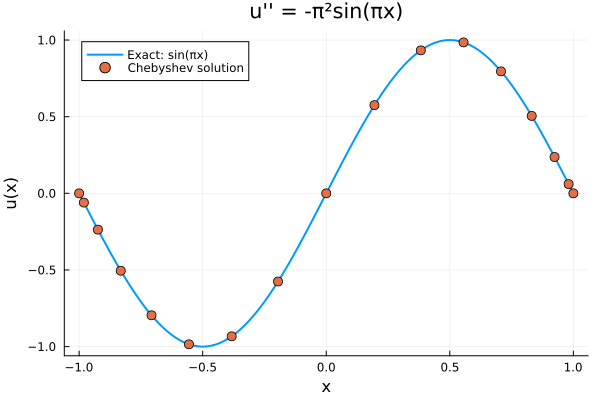

In [4]:
using Plots

# Dense grid for the exact solution
x_fine = range(-1, 1, length=200)
u_exact = sin.(π .* x_fine)

plot(x_fine, u_exact, label="Exact: sin(πx)", linewidth=2)
scatter!(X, u, label="Chebyshev solution", markersize=5)
xlabel!("x")
ylabel!("u(x)")
title!("u'' = -π²sin(πx)")

In [44]:
using LinearAlgebra

X = chebyshev_nodes(-1,1,20)
calculate_weights(Int(1),X[3],X)

# Compute weights and approximate the derivative
weights = calculate_weights(1, X[3], X)
f_values = sin.(X)
approx = dot(weights, f_values)
exact = cos(X[3])

println(weights)

println("x0 (3rd Chebyshev node): $X[3]")
println()
println("Approximate f'(x0):  $approx")
println("Exact f'(x0):        $exact")
println("Absolute error:      $(abs(approx - exact))")

[-10.21586454726538, 27.298667732483953, -4.9797965697654565, -16.652791531124983, 7.040294042680412, -4.099205106965183, 2.7527638409423503, -2.011805206337479, 1.5575365158350527, -1.2584599161585448, 1.05146222423827, -0.9029418901400228, 0.7936044933348396, -0.7117199556938546, 0.6498393924658127, -0.603076911374608, 0.5681580876808239, -0.5428695859059794, 0.5257311121191327, -0.5157976287833848, 0.256271407734227]
x0 (3rd Chebyshev node): Any[1.0, 0.9876883405951378, 0.9510565162951535, 0.8910065241883679, 0.8090169943749475, 0.7071067811865476, 0.5877852522924731, 0.45399049973954686, 0.30901699437494745, 0.15643446504023092, 6.123233995736766e-17, -0.1564344650402306, -0.30901699437494734, -0.45399049973954675, -0.587785252292473, -0.7071067811865475, -0.8090169943749473, -0.8910065241883678, -0.9510565162951535, -0.9876883405951377, -1.0][3]

Approximate f'(x0):  0.5808233782431589
Exact f'(x0):        0.5808233782431591
Absolute error:      2.220446049250313e-16


In [40]:
# Derivative tests for Fornberg (1998) Lagrange polynomial derivatives
# Bryan Kaiser
# 12/20/15

using DataArrays
using PyPlot
using PyCall
@pyimport numpy as np
@pyimport pylab as py


## ============================================================================
# function declaration

function weights(z,x,n,m)
# From Bengt Fornbergs (1998) SIAM Review paper.
#  	Input Parameters
#	z location where approximations are to be accurate,
#	x(0:nd) grid point locations, found in x(0:n)
#	n one less than total number of grid points; n must
#	not exceed the parameter nd below,
#	nd dimension of x- and c-arrays in calling program
#	x(0:nd) and c(0:nd,0:m), respectively,
#	m highest derivative for which weights are sought,
#	Output Parameter
#	c(0:nd,0:m) weights at grid locations x(0:n) for derivatives
#	of order 0:m, found in c(0:n,0:m)
#      	dimension x(0:nd),c(0:nd,0:m)

	c = zeros(n+1,m+1);
	c1 = 1.0;
	c4 = x[1+0]-z;
	for k=0:m
  		for j=0:n
    			c[1+j,1+k] = 0.0;
  		end
	end
	c[1+0,1+0] = 1.0;
	for  i=1:n
  		mn = min(i,m);
  		c2 = 1.0;
  		c5 = c4;
  		c4 = x[1+i]-z;
  		for j=0:i-1
    			c3 = x[1+i]-x[1+j];
    			c2 = c2*c3;
    			if (j == i-1)
      				for k=mn:-1:1
        				c[1+i,1+k] = c1*(k*c[1+i-1,1+k-1]-c5*c[1+i-1,1+k])/c2;
			      	end
      			c[1+i,1+0] = -c1*c5*c[1+i-1,1+0]/c2;
    			end
    			for k=mn:-1:1
      				c[1+j,1+k] = (c4*c[1+j,1+k]-k*c[1+j,1+k-1])/c3;
    			end
    			c[1+j,1+0] = c4*c[1+j,1+0]/c3;
  		end
  		c1 = c2;
	end
   	return c
end # weights function


## ============================================================================
# domain parameters

const Lx = 3000.0 # km, domain size
const Ly = Lx # km
const Lxcenter = 0.0 # x value @ the center of the grid
const Lycenter = 0.0 # y value @ the center of the grid
const N = 2^20 # series length (must be at least even)
const dx = Lx/float(N) # km, uniform longitudinal grid spacing
const dy = Ly/float(N) # km, uniform longitudinal grid spacing
x = collect(0.5*dx:dx:dx*N)-(Lx/2.0-Lxcenter) # km, centered uniform grid 


## ============================================================================
# signal

k = 2.0*pi/(Lx/5.0)
s = sin(x.*k)
dsdx = cos(x.*k).*k
d2sdx2 = -sin(x.*k).*k^2

figure(1)
plot(x,s,"b",x,dsdx,"r",x,d2sdx2,"g")
xlabel("x")
title("signal")
show()


##=============================================================================
# compute the uniform grid weights

c = weights(x[3],x[1:5],4,2)'; # 5 point stencil weights
dsF = zeros(1,N); # derivative of the input function
m = 1 # order of the derivative
   
dsF = zeros(Float64,N,1)
for j = 3:N-2      
	jm2 = j-2;
        jp2 = j+2;
        dsF[j,1] = vecdot(c[m+1,:],s[jm2:jp2]);
end
error = abs(dsdx-dsF)

@show(N)
figure(2)
semilogy(x[3:N-2],error[3:N-2],"k")
xlabel("x")
title("Lagrange polynomial 1st derivative error")
show()

LoadError: ArgumentError: Package PyPlot not found in current path.
- Run `import Pkg; Pkg.add("PyPlot")` to install the PyPlot package.

# The Finite Difference Method we're used to  
Given an ordinary differential equation, we discretize it via a finite difference approximation of the derivative and represent it as a matrix problem.

Using the Taylor Series Expansion of u(x+h) and u(x-h)  
where we assume the matrix is uniform and where u(x) = $u_i$, u(x-h) = $u_{i-1}$, and u(x+h) = $u_{i+1}$  
### Finite Difference for approximations of derivatives

$u'(t) = \frac{u_{i+1} - u_{i-1}}{2h} + O(h^2)$  

$u''(t) = \frac{u_{i-1} +2u_i + u_{i+1}}{h^2} + O(h^2)$  

Then we proceed with the normal numerical scheme, however,  
what if we use a non-uniform grid where the distance between points isn't h  

### Non-uniform grid choice
Chebyshev nodes of the second kind:
$x_i = cos(\frac{i \pi}{N})$ for i=0,1,...,N  
If n = 10
$x_0 = 1.0$  
$x_1 = 0.95$  
$x_2 = 0.81$  
$x_3 = 0.58$  
...  

So now if we try to find the central finite difference at $x_2$ for example, we see the step size to the left is different than that to the right  
$h_1 = |x_2 - x_1 | =  0.14$  
$h_2 = | x_2 - x_3 | = 0.23$  
$u(x-h_1)$ and $u(x+h_2)$  
and hence instead of simply doing the taylor series expansion of $u(x+h) - u(x-h)$ to cancel out $u''$,  
it becomes a problem of solving a linear system to determine the weights  

### Fornberg Algorithm

### Example

### Use on a non-uniform Boundary Value Problem

In [19]:
import Pkg; Pkg.add("DataArrays")

    Updating registry at `C:\Users\Brady\.julia\registries\General.toml`
   Resolving package versions...
   Installed JpegTurbo_jll ───────── v3.1.5+0
   Installed Libmount_jll ────────── v2.42.0+0
   Installed GR_jll ──────────────── v0.73.24+0
   Installed Opus_jll ────────────── v1.6.1+0
   Installed GR ──────────────────── v0.73.24
   Installed LERC_jll ────────────── v4.1.0+0
   Installed ConcurrentUtilities ─── v2.5.1
   Installed Preferences ─────────── v1.5.2
   Installed DataArrays ──────────── v0.7.0
   Installed Cairo_jll ───────────── v1.18.6+0
   Installed Xorg_libXinerama_jll ── v1.1.7+0
   Installed PlotUtils ───────────── v1.2.0
   Installed Missings ────────────── v0.4.5
   Installed OpenSSL ─────────────── v1.6.1
   Installed libva_jll ───────────── v2.23.0+0
   Installed Xorg_libxkbfile_jll ─── v1.2.0+0
   Installed Xorg_libpciaccess_jll ─ v0.18.1+0
   Installed xkbcommon_jll ───────── v1.13.0+0
   Installed Pango_jll ───────────── v1.57.1+0
   Installed XZ_jll ────